# Purpose:
- Too many neurons show reduced coding score on novelty.
    - Look at population mean responses to images and omissions
- Validate coding score


In [1]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
import glm_fit_tools as gft
import design_matrix_tools as dmtools
import kernel_tools as ktools
import load_data
import vba_tools

from sklearn.cluster import SpectralClustering

import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json

from matplotlib import pyplot as plt
import seaborn as sns

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils



In [2]:
data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('stim-response' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'

session_names = [rp.split('/')[-1] for rp in raw_paths]
session_keys = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'session_key': session_keys,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('session_key', drop=True, inplace=True)
session_info_df

,session_name,session_ind,session_type
session_key,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [3]:
session_ind_name_dict = {6: 'Familiar',
                         7: 'Novel',
                         8: 'Novel+1'}

In [4]:
roicat_df_fn = '/root/capsule/scratch/Thyme/roicat_df.pkl'
roicat_df = pd.read_pickle(roicat_df_fn)
f1n2_session_inds = [6, 7, 8]
f1n2_roi_df = roicat_df.query('valid_roi and (session_ind in @f1n2_session_inds) and matched')
f1n2_uc_series = f1n2_roi_df.groupby('unique_cell_name').size()
f1n2_matched_uc = f1n2_uc_series.index.values[np.where(f1n2_uc_series==len(f1n2_session_inds))[0]]
print(len(f1n2_matched_uc))
f1n2_all_matched_roi_df = f1n2_roi_df.query('unique_cell_name in @f1n2_matched_uc')
f1n2_all_matched_roi_df.head()

291


,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key_x,session_ind,unique_cell_name,cell_roi_id,valid_roi,exclusion_labels,touching_motion_border,small_roi,session_key_y,plane_session_key,session_key
roi_name,,,,,,,,,,,,,,,,,,,,
736963_2024-08-09_VISp_0_0005,5,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,5,88,db55ec77-70e9-4e64-8e7f-caa9660a4d5e,0.992339,0.976572,True,736963_2024-08-09,8,VISp_0_0088,5,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0007,7,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,7,101,f2aabcb6-bfb4-40ee-9ea1-e7f420475ab5,0.902556,1.000000,True,736963_2024-08-09,8,VISp_0_0101,7,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0008,8,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,8,98,fb45dc23-e4d5-4ebf-a5a9-b0c3c4eb36ff,0.982731,1.000000,True,736963_2024-08-09,8,VISp_0_0098,8,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0009,9,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,9,99,8483a820-9d1f-4576-ae40-7b868e611d9e,0.917262,1.000000,True,736963_2024-08-09,8,VISp_0_0099,9,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0010,10,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,10,3,127fcf28-5de9-480a-8218-3a5850abeaf5,0.985113,0.968638,True,736963_2024-08-09,8,VISp_0_0003,10,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09


# Mean responses

In [13]:
mean_response_path = Path('/root/capsule/data/single_cell_mean_responses_736963_natural_images_condition_v0')
mean_response_df = pd.DataFrame()
for session_ind in session_ind_name_dict.keys():
    session_name = session_info_df.query(f'session_ind=={session_ind}').session_name.values[0]
    mean_response_fn = mean_response_path / f'response_v0_{session_name}.feather'
    temp_response_df = pd.read_feather(mean_response_fn)
    conditions = temp_response_df.condition.unique()
    image_condition = [condition for condition in conditions if 'image' in condition][0]
    temp_response_df.loc[temp_response_df.condition==image_condition, 'condition'] = 'all-images'
    temp_response_df['session_ind'] = session_ind
    temp_response_df['experience_level'] = session_ind_name_dict[session_ind]
    mean_response_df = pd.concat([mean_response_df, temp_response_df])
    

In [22]:
[len(ts) for ts in mean_response_df.groupby('session_ind').timestamps.mean().values]

[65, 65, 65]

In [31]:
timestamps_sessions = [ts.round(2) for ts in mean_response_df.groupby('session_ind').timestamps.mean().values]
[ts==timestamps_sessions[0] for ts in timestamps_sessions]

[array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True]),
 array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True, Fal

In [39]:
common_timestamps = timestamps_sessions[0]

### There's a little mis-alignment but I can live with it for now
- No need for interpolation

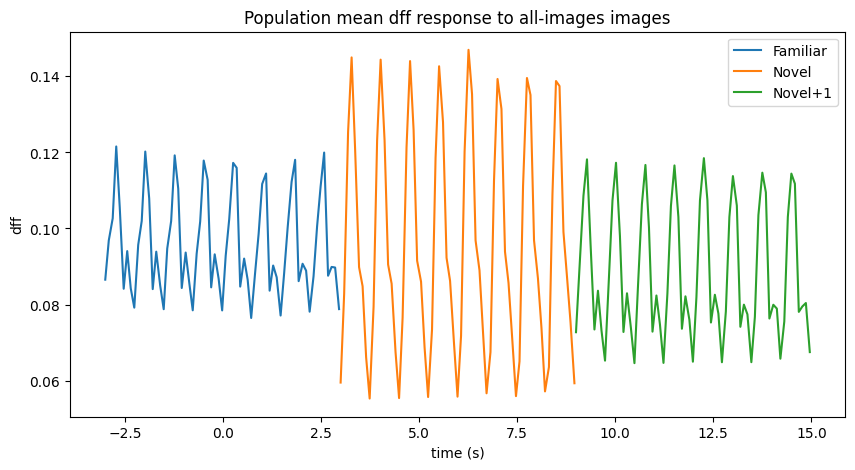

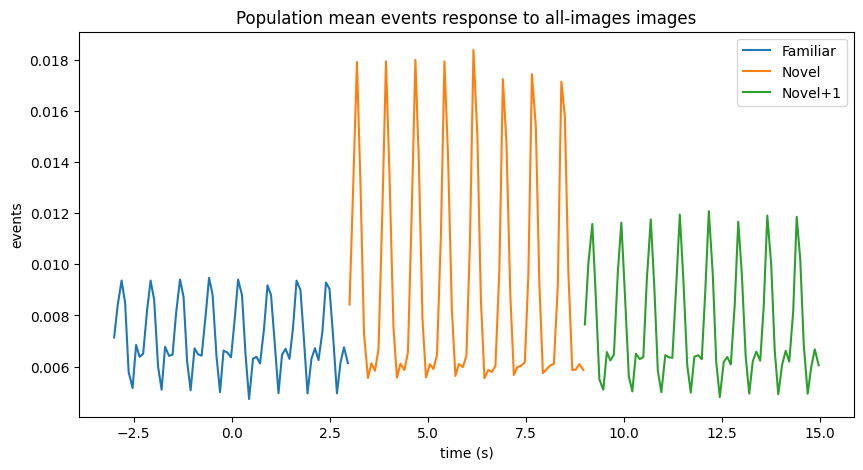

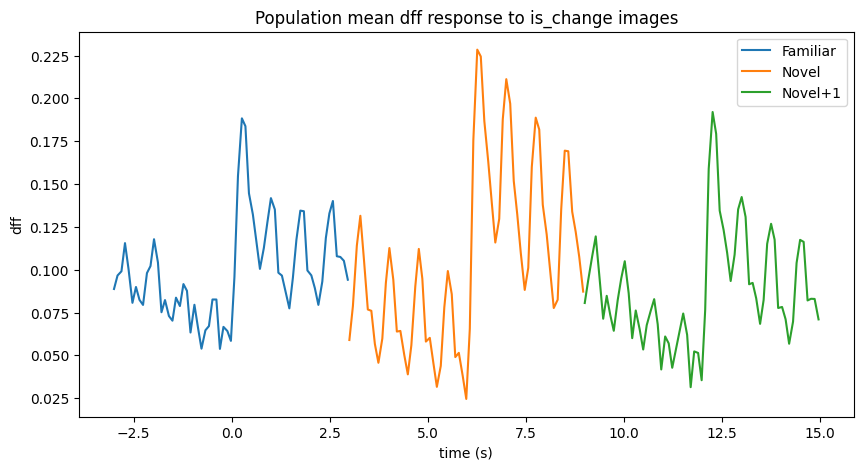

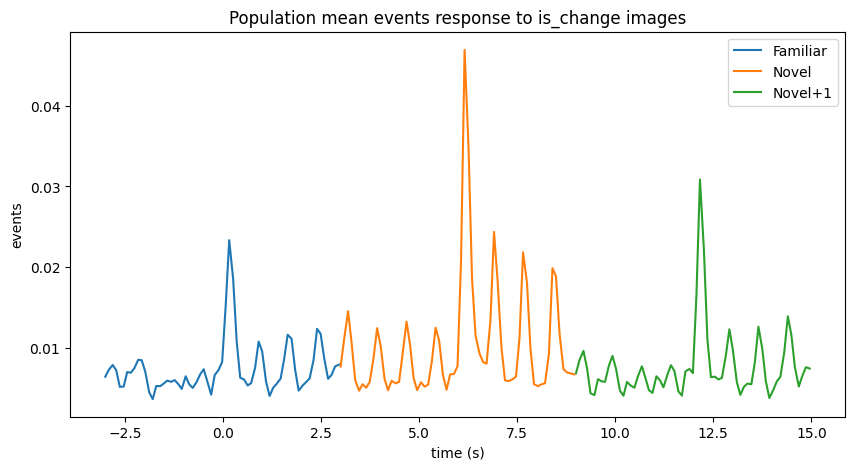

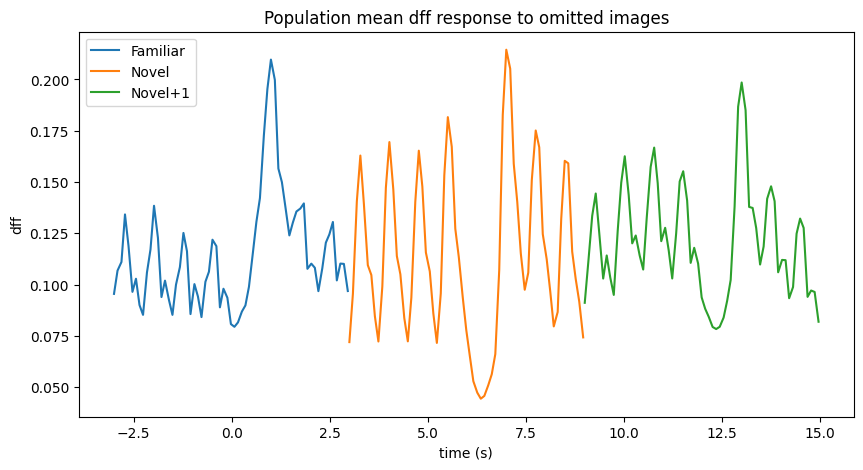

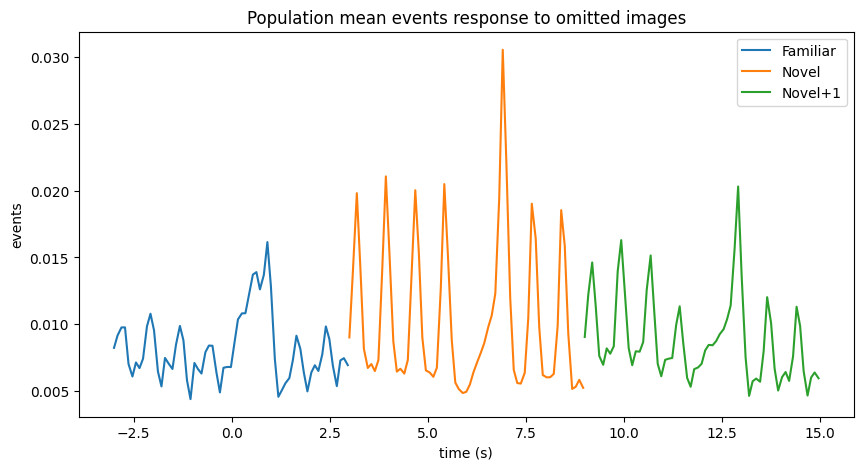

In [64]:
conditions = mean_response_df.condition.unique()
data_types = mean_response_df.data_type.unique()
for condition in conditions:
    for data_type in data_types:
        mean_responses = mean_response_df.query(f'condition=="{condition}" and data_type=="{data_type}"').groupby('session_ind')[['mean_trace']].mean()
        sem_responses = pd.DataFrame(mean_response_df.query(f'condition=="{condition}" and data_type=="{data_type}"').groupby(
            'session_ind')[['mean_trace']].apply(
                lambda x: np.std(x.values)/x.values.shape[0]))
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))        
        for si in range(3):
            x = common_timestamps + si * 6
            mean = mean_responses.iloc[si].values[0]
            sem = sem_responses.iloc[si].values[0]
            ax.fill_between(x, mean - sem, mean + sem, alpha=0.5)
            ax.plot(x, mean, label=session_ind_name_dict[list(session_ind_name_dict.keys())[si]])
        ax.legend()
        ax.set_xlabel('time (s)')
        ax.set_ylabel(data_type)
        ax.set_title(f'Population mean {data_type} response to {condition} images')


# Look at coding score distribution
- both matched and unmatched population

In [68]:
dm_version = 1
data_type = 'events'
suffix = '00'

include_models = ['all-images', 'omissions', 'behavioral', 'task']

coding_score_table = f1n2_all_matched_roi_df.reset_index()[['roi_name', 'unique_cell_name', 'session_ind', 'session_key', 'fov_name', 'roi_session_index']].copy()

session_keys = np.sort(coding_score_table.session_key.unique())

coding_scores_all_sessions = []

coding_score_raw = None
for session_key in session_keys:
    session_matched_roi_name = ['_'.join(rn.split('_')[-3:]) for rn in f1n2_all_matched_roi_df.query(f'session_key=="{session_key}"').index.values]
    
    session_name = session_info_df.loc[session_key, 'session_name']
    session_ind = session_info_df.loc[session_key, 'session_ind']
    coding_score_fn = Path(glm_dir) / f'coding_score_736963_natural_images_v01_events/coding_score_v{dm_version:02}_{session_name}_{data_type}_{suffix}.nc'
    with xr.open_dataarray(coding_score_fn) as ds:
        coding_score_session = ds.expand_dims('session').assign_coords(session=[session_ind_name_dict[session_ind]])
        cell_roi_ids = coding_score_session.cell_roi_id.values
        
        # get filtered cell_roi_ids during glm fitting (<1% active frames)
        X, response, response_info, run_params, unstd_features, use_indices = \
            gft.load_data(session_name, data_type, dm_version, load_path=glm_dir)
        response_trim = response[use_indices, :]
        response_trim_filtered = gft.filter_response_matrix(response_trim)
        filtered_cell_roi_id = np.setdiff1d(response_trim.cell_roi_id.values, response_trim_filtered.cell_roi_id.values)
        
        # if there are missing cell_roi_ids among filtered cell_roi_ids, add them to coding_score_session and fill with 0
        missing_cell_roi_ids = np.setdiff1d(filtered_cell_roi_id, cell_roi_ids)
        if len(missing_cell_roi_ids) > 0:
            new_cell_roi_ids = np.concatenate([cell_roi_ids, missing_cell_roi_ids])
            coding_score_session = coding_score_session.reindex(cell_roi_id=new_cell_roi_ids, fill_value=0)
        
        # Collect coding scores
        coding_scores_all_sessions.append(coding_score_session)
        
        # Choose only the matched cell_roi_ids
        coding_score_session = coding_score_session.sel(cell_roi_id=session_matched_roi_name, model=include_models).copy()
        
        # Swap cell_roi_id which is session-specific to unique_cell_name for concatenation across sessions
        unique_cell_names = []
        for cell_roi_id in coding_score_session.cell_roi_id.values:
            roi_name = f'{session_key}_{cell_roi_id}'
            unique_cell_names.append(f1n2_all_matched_roi_df.loc[roi_name, 'unique_cell_name'])

        coding_score_session = coding_score_session.assign_coords(unique_cell_name=("cell_roi_id", unique_cell_names))
        coding_score_session = coding_score_session.swap_dims({"cell_roi_id": "unique_cell_name"})
        coding_score_session = coding_score_session.reset_coords('cell_roi_id', drop=True)
    if coding_score_raw is None:
        coding_score_raw = coding_score_session
    else:
        coding_score_raw = xr.concat([coding_score_raw, coding_score_session], dim='session')
        
max_full_score = coding_score_raw.max(dim='session')
assert len(np.where(coding_score_raw.isnull())[0]) == 0

Text(0.5, 0.98, 'Coding score distribution for all neurons from each session (Thyme)')

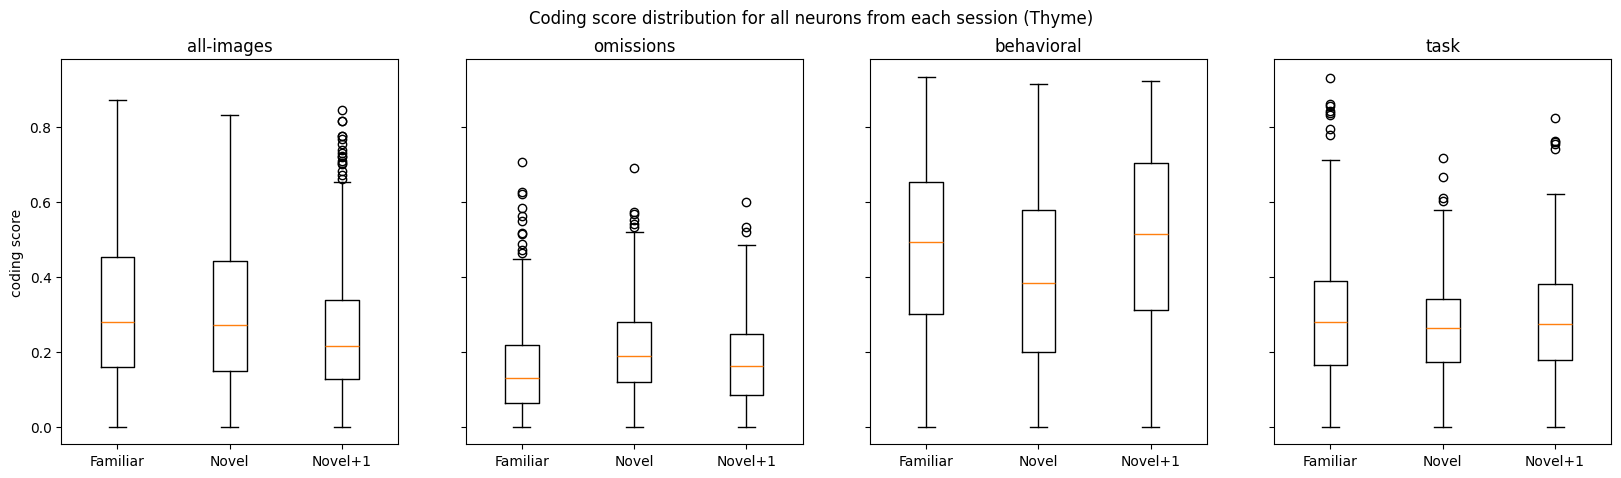

In [86]:
fig, ax = plt.subplots(1,4, figsize=(20, 5), sharey=True)
for mi, model in enumerate(include_models):    
    values = []
    for i in range(3):
        values.append(-coding_scores_all_sessions[i].sel(model=model, metric='coding_score').values.flatten())
    ax[mi].boxplot(values)
    ax[mi].set_xticklabels(session_ind_name_dict.values())
    ax[mi].set_title(model)
ax[0].set_ylabel('coding score')
fig.suptitle('Coding score distribution for all neurons from each session (Thyme)')

Text(0.5, 0.98, 'Adj. VE of full model for all neurons from each session (Thyme)')

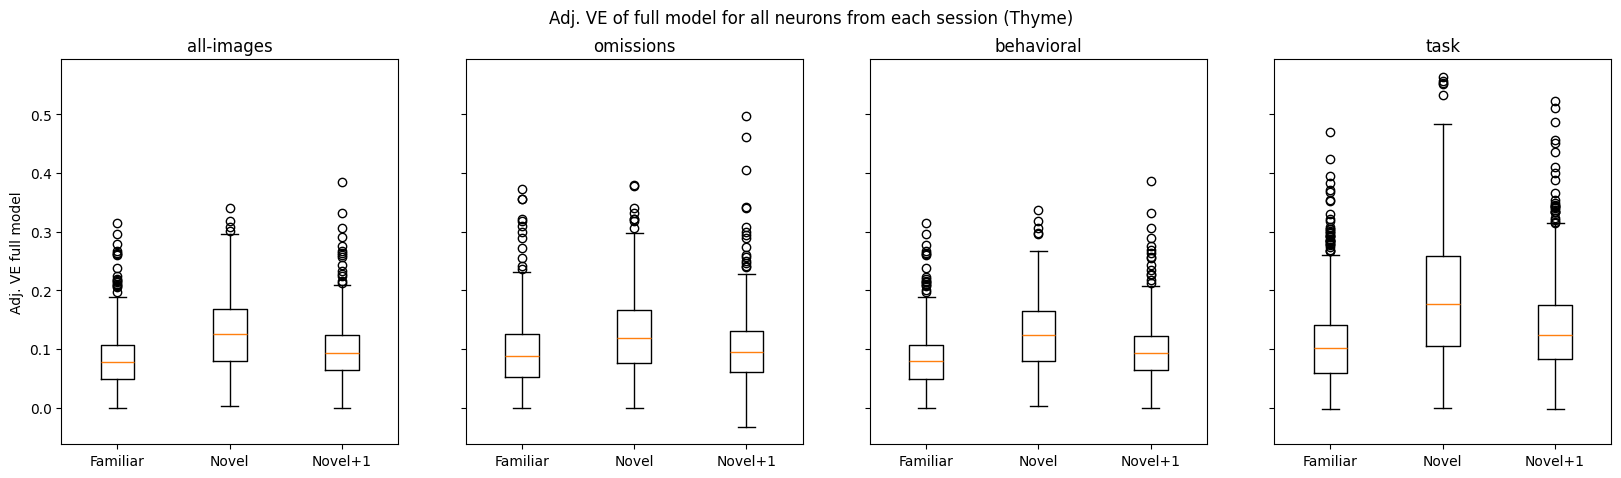

In [92]:
# Pretty similar coding scores across sessions
# What about full model explained variance? (within each support)
fig, ax = plt.subplots(1,4, figsize=(20, 5), sharey=True)
for mi, model in enumerate(include_models):    
    values = []
    for i in range(3):
        values.append(coding_scores_all_sessions[i].sel(model=model, metric='adj_ve_full').values.flatten())
    ax[mi].boxplot(values)
    ax[mi].set_xticklabels(session_ind_name_dict.values())
    ax[mi].set_title(model)
ax[0].set_ylabel('Adj. VE full model')
fig.suptitle('Adj. VE of full model for all neurons from each session (Thyme)')

In [98]:
coding_score_raw.isel(unique_cell_name=0, model=0)

<xarray.DataArray 'coding_score_metrics_from_session_model' (session: 3,
                                                             metric: 3)> Size: 72B
array([[ 0.02723944,  0.06905866, -0.60556078],
       [ 0.04253683,  0.12130405, -0.64933708],
       [ 0.02971529,  0.05488265, -0.45856668]])
Coordinates:
    model             <U10 40B 'all-images'
  * metric            (metric) object 24B 'adj_ve_model' ... 'coding_score'
    unique_cell_name  <U11 44B 'VISp_0_0003'
  * session           (session) <U8 96B 'Familiar' 'Novel' 'Novel+1'

In [97]:
# check max full adjve
max_full_score.isel(unique_cell_name=0, model=0)

<xarray.DataArray 'coding_score_metrics_from_session_model' (metric: 3)> Size: 24B
array([ 0.04253683,  0.12130405, -0.45856668])
Coordinates:
    model             <U10 40B 'all-images'
  * metric            (metric) object 24B 'adj_ve_model' ... 'coding_score'
    unique_cell_name  <U11 44B 'VISp_0_0003'

In [121]:
# Normalized coding score
coding_score_normalized = \
    -((coding_score_raw.sel(metric='adj_ve_full') - coding_score_raw.sel(metric='adj_ve_model')) / coding_score_raw.sel(metric='adj_ve_full').max(dim='session'))    
    
# filtering
filter_threshold = 0.005
mask_from_max = max_full_score.sel(metric='adj_ve_full') < filter_threshold
sessions = coding_score_raw.session.values
mask_from_max = xr.concat([mask_from_max] * len(sessions), dim="session")
mask_from_max = mask_from_max.assign_coords(session=sessions)
mask_from_raw = coding_score_raw.sel(metric='adj_ve_model') < filter_threshold

coding_score_normalized_filtered = coding_score_normalized.where(~(mask_from_max + mask_from_raw), other=0)

# clipping
coding_score_normalized_filtered_clipped = coding_score_normalized_filtered.clip(min=-1, max=0)
assert len(np.where(coding_score_normalized_filtered_clipped.isnull())[0]) == 0

Text(0.5, 0.98, 'Cross-session normalized coding score distribution for matched neurons (Thyme)')

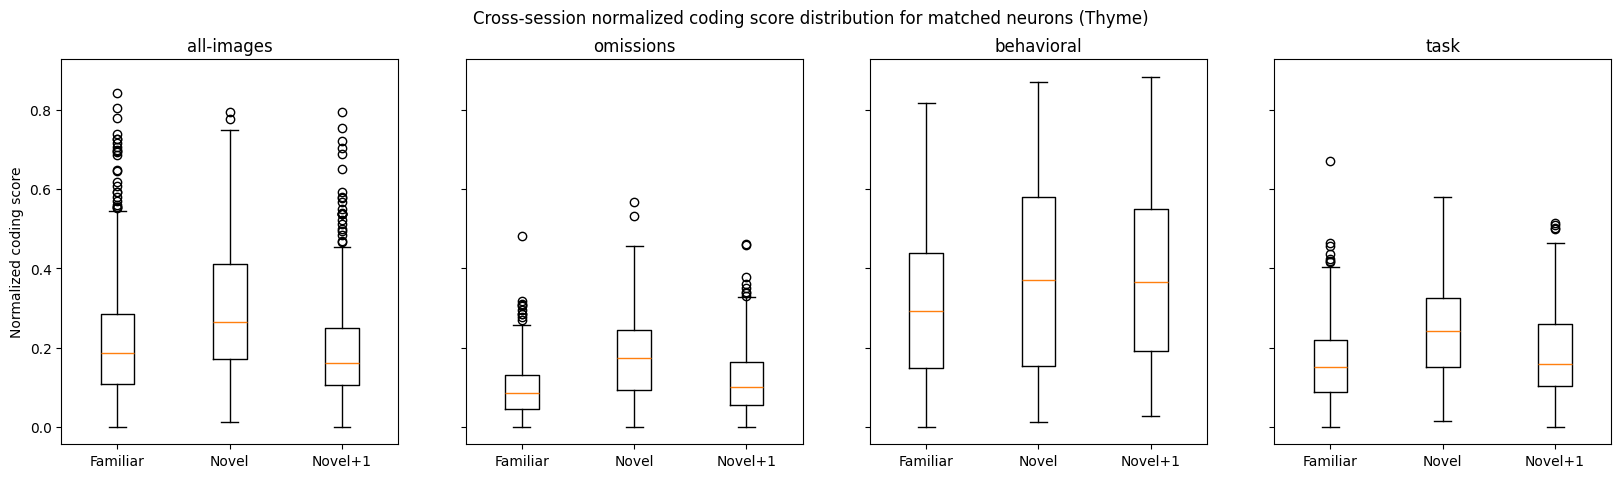

In [122]:
fig, ax = plt.subplots(1,4, figsize=(20, 5), sharey=True)
sessions = list(session_ind_name_dict.values())
for mi, model in enumerate(include_models):    
    values = []
    for si in range(3):
        session = sessions[si]
        values.append(-coding_score_normalized_filtered_clipped.sel(session=session, model=model).values.flatten())
    ax[mi].boxplot(values)
    ax[mi].set_xticklabels(sessions)
    ax[mi].set_title(model)
ax[0].set_ylabel('Normalized coding score')
fig.suptitle('Cross-session normalized coding score distribution for matched neurons (Thyme)')

# Conclusion
- Error was in the normalization process. (now corrected)